# GraphForecastingModel + Trainer Synthetic Demo

This notebook builds a small graph-coupled synthetic time series, trains the new `GraphForecastingModel` through the regular `Trainer`, and plots held-out forecasts against the true future values.

The important part is that the dataloader yields graph kwargs (`edge_index`) in each batch, and `Trainer` forwards them to `GraphForecastingModel` during training and validation.

In [1]:
import math
import os
import sys

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from foreblocks.config import TrainingConfig
from foreblocks.models import GraphForecastingModel
from foreblocks.training.trainer import Trainer

torch.manual_seed(12)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [2]:
def make_ring_edge_index(num_nodes: int) -> torch.Tensor:
    edges = []
    for node in range(num_nodes):
        edges.append(((node - 1) % num_nodes, node))
        edges.append((node, node))
        edges.append(((node + 1) % num_nodes, node))
    return torch.tensor(edges, dtype=torch.long).t().contiguous()


def make_graph_series(length: int = 520, num_nodes: int = 6, noise: float = 0.035):
    edge_index = make_ring_edge_index(num_nodes)
    time = torch.arange(length, dtype=torch.float32)
    phase = 2.0 * math.pi * torch.arange(num_nodes, dtype=torch.float32) / num_nodes

    seasonal = torch.sin(2.0 * math.pi * time[:, None] / 32.0 + phase[None, :])
    fast = 0.35 * torch.sin(2.0 * math.pi * time[:, None] / 9.0 - 0.4 * phase[None, :])
    slow = 0.45 * torch.sin(2.0 * math.pi * time[:, None] / 96.0 + 0.2 * phase[None, :])
    trend = 0.25 * (time[:, None] / length) * torch.linspace(0.7, 1.25, num_nodes)[None, :]

    base = seasonal + fast + slow + trend
    series = base.clone()
    for t in range(1, length):
        left = base[t - 1, torch.arange(num_nodes) - 1]
        right = base[t - 1, (torch.arange(num_nodes) + 1) % num_nodes]
        series[t] = 0.72 * base[t] + 0.14 * left + 0.14 * right

    series = series + noise * torch.randn_like(series)
    mean = series[:360].mean(dim=0, keepdim=True)
    std = series[:360].std(dim=0, keepdim=True).clamp_min(1e-6)
    series = (series - mean) / std
    return series.unsqueeze(-1), edge_index


series, edge_index = make_graph_series()
print(series.shape, edge_index.shape)

torch.Size([520, 6, 1]) torch.Size([2, 18])


In [3]:
seq_len = 36
horizon = 12
num_nodes = series.size(1)


class GraphWindowDataset(Dataset):
    def __init__(self, values: torch.Tensor, start: int, stop: int):
        self.values = values
        self.indices = list(range(start, stop - seq_len - horizon + 1))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        x = self.values[start : start + seq_len]
        y = self.values[start + seq_len : start + seq_len + horizon]
        return x, y


def collate_graph_batch(batch):
    x, y = zip(*batch)
    return {
        "X": torch.stack(x, dim=0),
        "y": torch.stack(y, dim=0),
        "edge_index": edge_index,
    }


train_end = 390
val_start = train_end - seq_len

train_ds = GraphWindowDataset(series, start=0, stop=train_end)
val_ds = GraphWindowDataset(series, start=val_start, stop=520)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_graph_batch)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_graph_batch)

batch = next(iter(train_loader))
print(batch["X"].shape, batch["y"].shape, batch["edge_index"].shape)

torch.Size([32, 36, 6, 1]) torch.Size([32, 12, 6, 1]) torch.Size([2, 18])


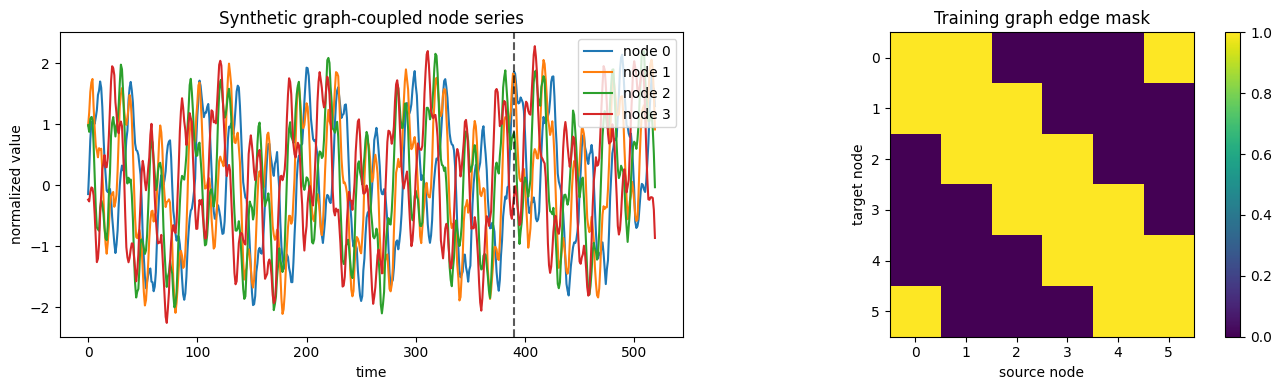

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for node in range(min(num_nodes, 4)):
    axes[0].plot(series[:, node, 0], label=f"node {node}")
axes[0].axvline(train_end, color="black", linestyle="--", alpha=0.65)
axes[0].set_title("Synthetic graph-coupled node series")
axes[0].set_xlabel("time")
axes[0].set_ylabel("normalized value")
axes[0].legend(loc="upper right")

adj = torch.zeros(num_nodes, num_nodes)
adj[edge_index[1], edge_index[0]] = 1.0
im = axes[1].imshow(adj, cmap="viridis")
axes[1].set_title("Training graph edge mask")
axes[1].set_xlabel("source node")
axes[1].set_ylabel("target node")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()

In [5]:
model = GraphForecastingModel(
    num_nodes=num_nodes,
    feat_dim=1,
    hidden_size=24,
    out_feat_dim=1,
    graph_source="external",
    conv=["gcn", "sage", "gat"],
    gat_heads=3,
    jk="concat",
    dropout=0.05,
    stochastic_depth=0.05,
    seq_len=seq_len,
    horizon=horizon,
)

config = TrainingConfig(
    num_epochs=25,
    learning_rate=2e-3,
    weight_decay=1e-4,
    batch_size=32,
    patience=8,
    use_amp=False,
)

trainer = Trainer(model, config=config, device=device, auto_track=False)
history = trainer.train(train_loader, val_loader)

[MLTracker] Resolved mltracker_uri to: /data/dev/foreblocks/foreblocks/mltracker/mltracker_data


Training: 100%|██████████| 25/25 [00:00<00:00, 25.55epoch/s, train=0.0199, val=0.0466, lr=0.002]


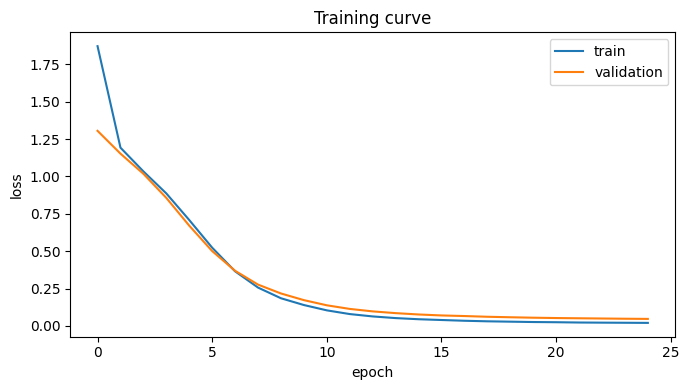

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(history.train_losses, label="train")
if history.val_losses:
    plt.plot(history.val_losses, label="validation")
plt.title("Training curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()

In [7]:
X_plot = torch.stack([val_ds[idx][0] for idx in range(len(val_ds))], dim=0)
y_plot = torch.stack([val_ds[idx][1] for idx in range(len(val_ds))], dim=0)
graph_kwargs = {"edge_index": edge_index}

metrics = trainer.metrics(X_plot, y_plot, graph_kwargs=graph_kwargs)
metrics

{'mse': 0.04657859727740288,
 'rmse': 0.21582075265692796,
 'mae': 0.17951364815235138,
 'mape': 129.76983785629272}

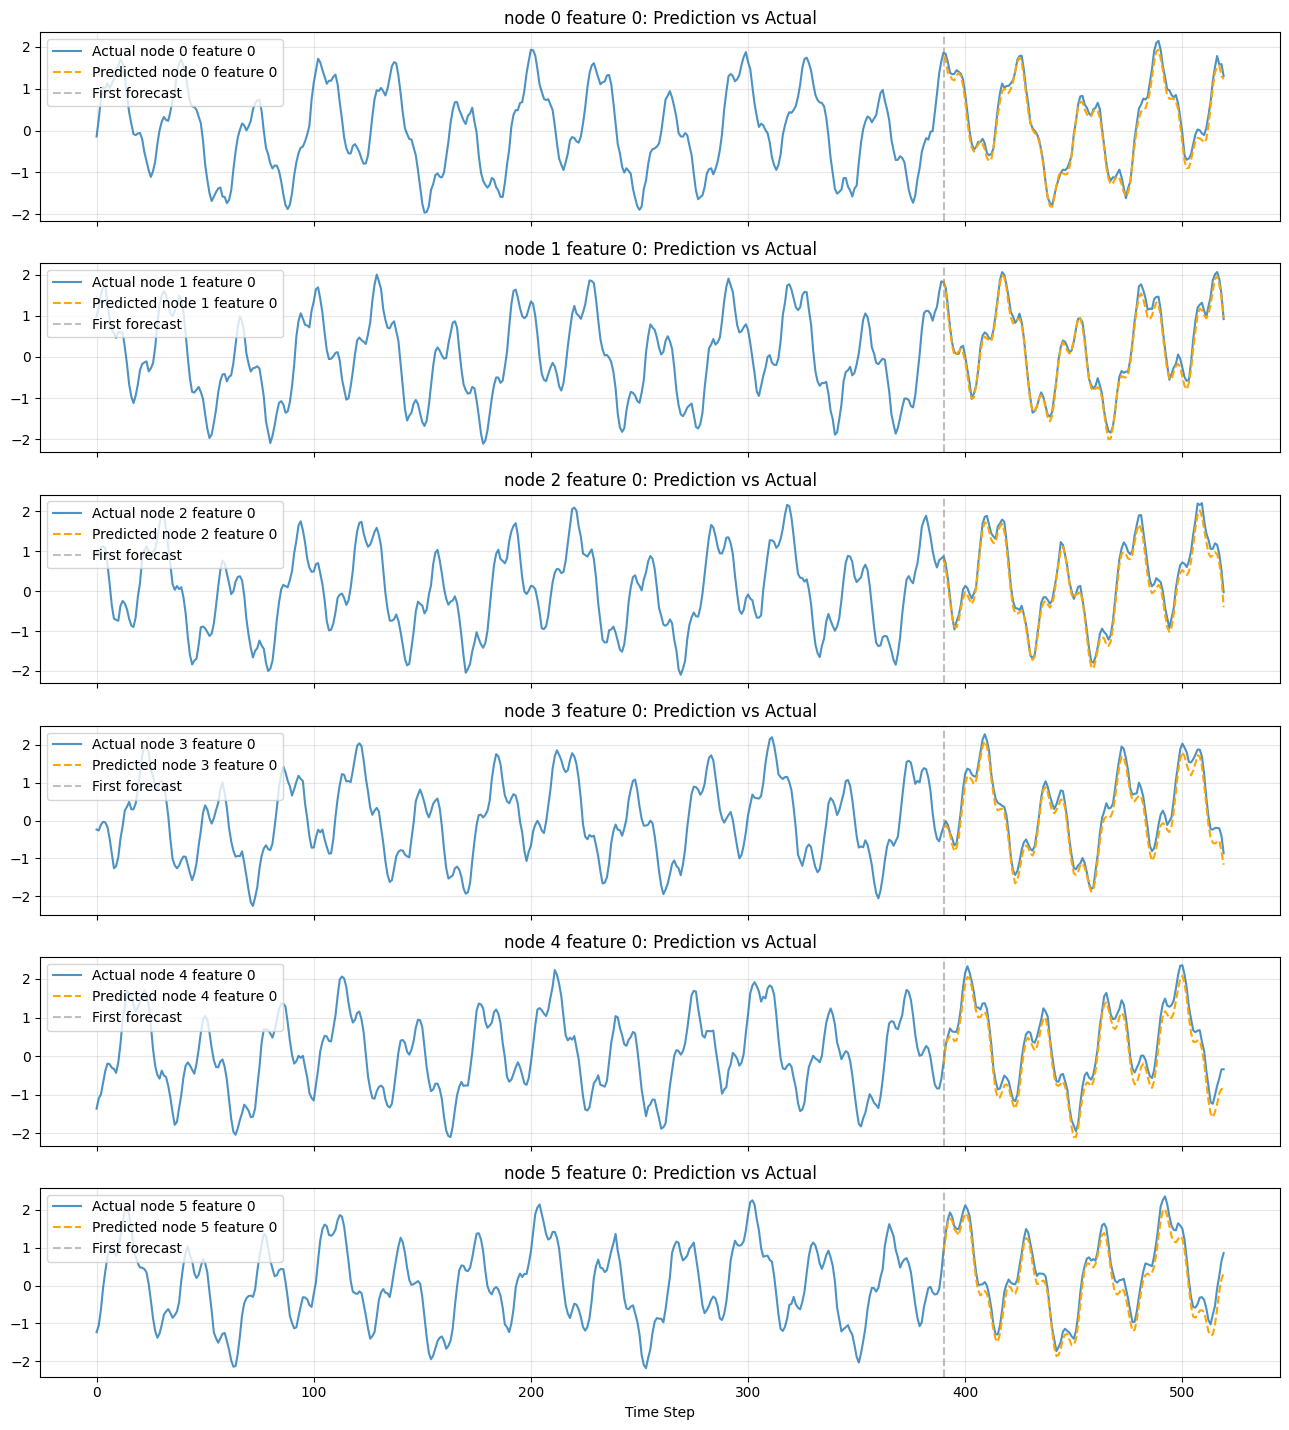

The dashed forecast is stitched from all validation windows over the full series.


In [8]:
node_names = [f"node {idx}" for idx in range(num_nodes)]
fig = trainer.plot_prediction(
    X_plot,
    y_plot,
    graph_kwargs=graph_kwargs,
    full_series=series,
    offset=val_ds.indices[0],
    stride=1,
    names=node_names,
    figsize=(13, 2.4),
)

print("The dashed forecast is stitched from all validation windows over the full series.")